# Import Libraries

In [39]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import fetch_california_housing

# Data preprocessing
from sklearn.model_selection import train_test_split

# Model
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import r2_score

from sklearn.inspection import permutation_importance

import shap

from lime.lime_tabular import LimeTabularExplainer

from IPython.display import HTML, display

# Load Dataset

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# Data Exploration

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [6]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

# Dataset Preparation

In [7]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.3, random_state=42)

# Random Forest Training

In [9]:
model_rf= RandomForestRegressor(n_estimators=200, random_state=42)
model_rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

# Randome Forest Model Evaluation

In [10]:
predict_rf = model_rf.predict(X_test)
r2 = r2_score(y_true=y_test, y_pred=predict_rf)
r2

0.7780996978472849

# Built-in Feature Importance

In [11]:
feature_importance_rf = pd.DataFrame({"Feature":X.columns, 
                                     "Importance": model_rf.feature_importances_})
sorted_importance_rf = feature_importance_rf.sort_values("Importance", 
                                                         ascending=False)

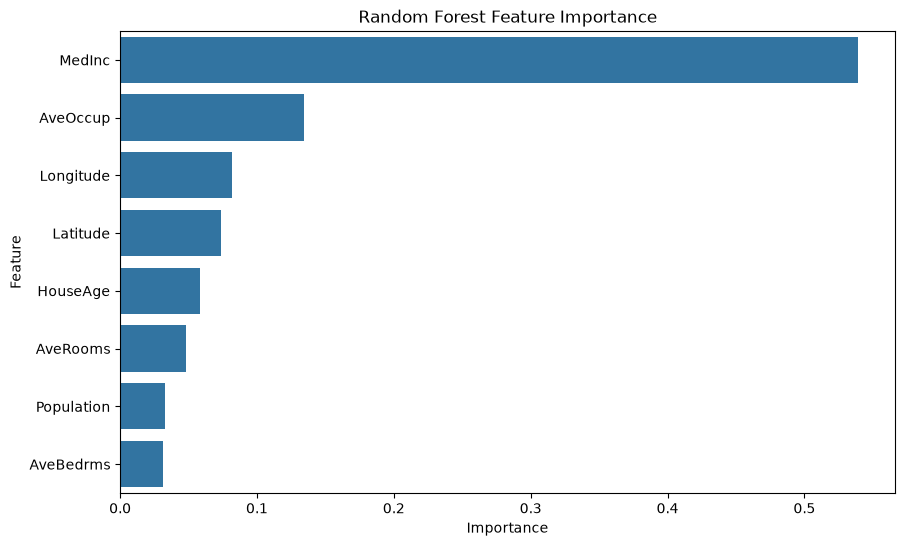

In [12]:
plt.figure(figsize=(10,6))
sns.barplot(data=sorted_importance_rf, x="Importance", y="Feature")
plt.title("Random Forest Feature Importance")
plt.show()

# SHAP (SHapley Additive exPlanations)

SHAP (SHapley Additive exPlanations) is a game-theoretic framework used to explain the predictions of machine learning models. It calculates "Shapley values" to determine how much each individual feature (like age, income, or temperature) contributes to a specific model outcom

In [13]:
explainer_shap = shap.TreeExplainer(model_rf)
shap_values = explainer_shap.shap_values(X_test)

# Shap Summary Plot

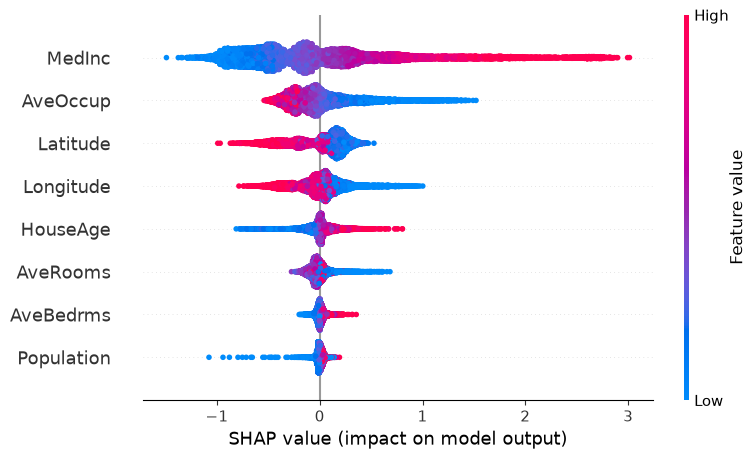

In [14]:
shap.summary_plot(shap_values, X_test)

# Shap Bar Plot

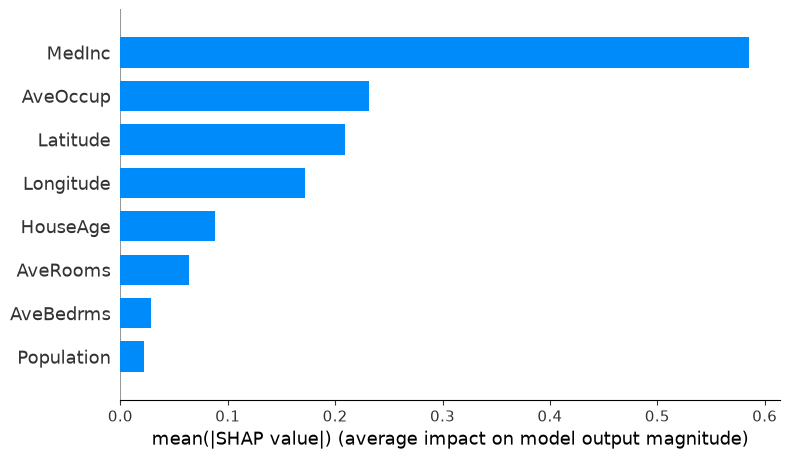

In [15]:
shap.summary_plot(shap_values, X_test, plot_type = "bar")

# SHAP Dependence Plot

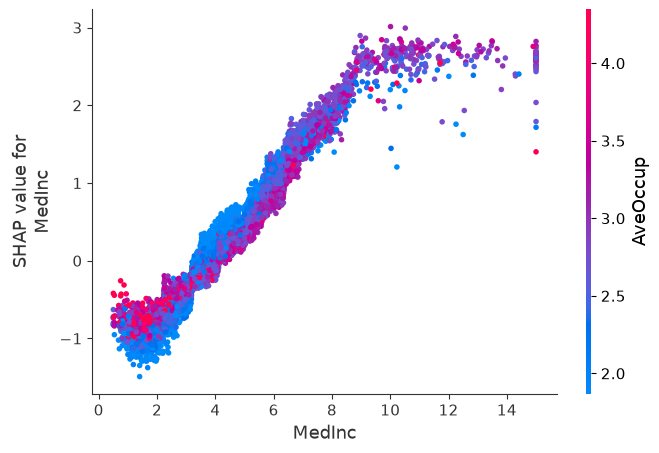

In [17]:
shap.dependence_plot("MedInc", shap_values, X_test)

Y-axis: SHAP Value for MedInc

The SHAP value measures how much MedInc contributes to the prediction.

Positive SHAP value → increases the predicted house value.
Negative SHAP value → decreases the predicted house value.
Zero → little or no effect.

1. Low Median Income

On the left side: MedInc ≈ 1–3. Most SHAP values are negative.
This means: Low median income tends to reduce the model's predicted house value.

2. Medium Median Income

Around MedInc ≈ 4–8, the SHAP values rise almost linearly.

This indicates: As median income increases, the model predicts higher house values.
This is exactly what we would expect in the real world.

3. High Median Income

Beyond MedInc ≈ 9, the curve begins to flatten.

This suggests: Increasing income beyond this point still raises the prediction, but the effect becomes smaller.
This is called a saturation effect or diminishing returns.

# SHAP Waterfall Plot (Single Prediction)

In [29]:
sample = 5
explanation_sample = explainer_shap(X_test.iloc[[sample]])

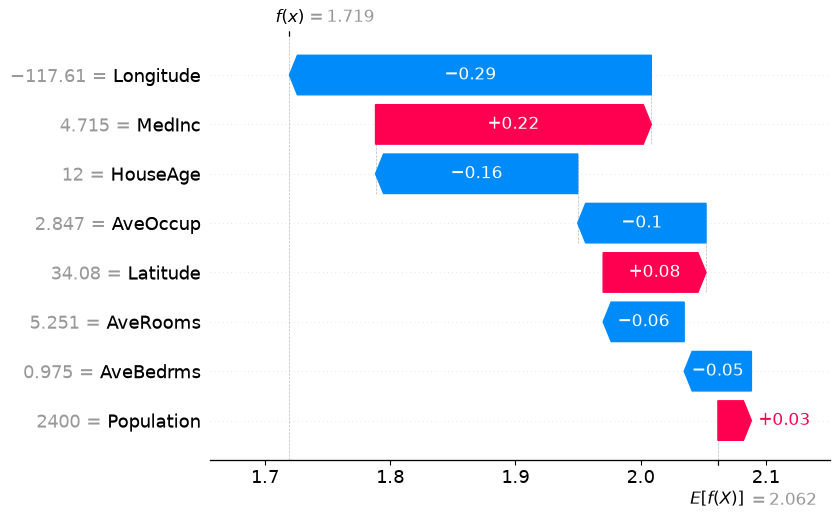

In [30]:
shap.waterfall_plot(explanation_sample[0])

Base value: The base value is the average prediction of the model across the entire training dataset.
The base value is shown at the bottom right of the figure: E[f(X)] = 2.062

Positive Contributions (Red Bars). Red bars indicate features that increase the prediction above the base value.
For this particular house:
    The neighborhood has a moderately high median income, which raises the predicted value.
    Its latitude contributes slightly positively.
    The population adds a small positive contribution.

Negative Contributions (Blue Bars). Blue bars indicate features that decrease the prediction below the base value.
For this particular house:
    The strongest factor lowering the prediction is Longitude.
    Other characteristics, such as the house age and occupancy, also reduce the predicted value.

Business Interpretation
For this house:
    The average predicted house value in the dataset is 2.062.
    A moderately high median income increases the predicted value.
    However, the location (longitude) is the strongest factor reducing the prediction.
    Other characteristics, including house age, average occupancy, average rooms, and average bedrooms, further lower the predicted value.
    After combining all positive and negative influences, the model predicts a house value of 1.719.

# LIME (Local Interpretable Model-agnostic Explanations)

LIME (Local Interpretable Model-agnostic Explanations) is a technique used in Explainable AI designed to demystify complex machine learning models. It works by approximating a "black-box" model (like a deep neural network) with a simpler, easy-to-understand local model.

In [34]:
explainer_lime = LimeTabularExplainer(X_train.values, feature_names=X.columns, mode="regression")

In [37]:
explainer_lime_sample = explainer_lime.explain_instance(X_test.iloc[5].values, model_rf.predict)

c:\ML-exploration\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [41]:
html = explainer_lime_sample.as_html()
display(HTML(html))

The model predicts a house value of 1.72, which is below the dataset's average prediction.

This prediction is primarily influenced by:

Positive factors
Latitude (+0.21)
Population (+0.01)

Negative factors
Longitude (−0.30) — strongest negative influence
HouseAge (−0.20)
Average Occupancy (−0.12)
Average Rooms (−0.10)
Median Income (−0.07)
Average Bedrooms (−0.05)

The combined effect of the negative factors outweighs the positive factors, resulting in the final prediction of 1.72.

# Permutation Importance

In [42]:
explanation_perm = permutation_importance(model_rf, X_test, y_test, n_repeats=10, random_state=42)

In [47]:
perm_df = pd.DataFrame({"Feature": X.columns, "Importance": explanation_perm.importances_mean})

In [48]:
perm_df.sort_values("Importance", ascending=False)

,Feature,Importance
0,MedInc,0.903001
6,Latitude,0.267928
7,Longitude,0.206439
5,AveOccup,0.197154
1,HouseAge,0.069962
2,AveRooms,0.024179
3,AveBedrms,0.007935
4,Population,0.007595


<Axes: xlabel='Importance', ylabel='Feature'>

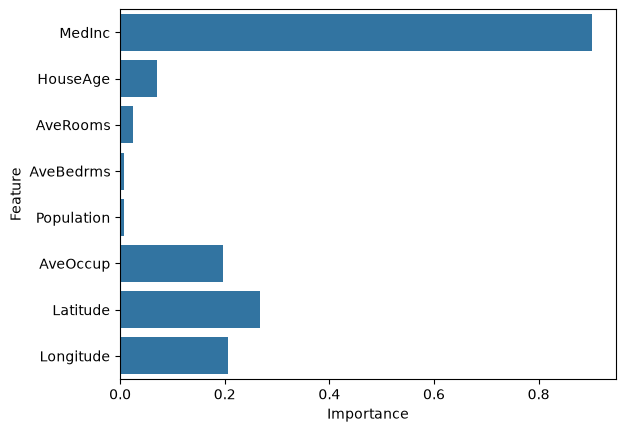

In [49]:
sns.barplot(data=perm_df, x="Importance", y="Feature")

# Comparisons

| Method                 | Global   | Local | Model Agnostic | Fast     |
| ---------------------- | ------   | ----- | -------------- | -------- |
| Feature Importance     | Yes      | No    | No             | Yes      |
| SHAP                   | Yes      | Tes   | Yes            | Moderate |
| LIME                   | No       | Yes   | Yes            | Moderate |
| Permutation Importance | Yes      | No    | Yes            | Moderate |